In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import holidays
import os

#1. Paths configuration
base_dir = os.path.dirname(os.getcwd())
data_path = os.path.join(base_dir, 'datasets', 'Dati.csv')
output_path = os.path.join(base_dir, 'datasets', 'Dati_processed.csv')

In [ ]:
# 2. Data Loading
df = pd.read_csv(data_path, sep=';',decimal=',')

# 3. Dynamic Scale Fix
cols_to_check = ['DesiredCapacity', 'CapacityUtilization', 'InUseCapacity', 'ActualCapacity', 'AvailableCapacity']
for col in cols_to_check:
    if col in df.columns:
        limite = 150 if col == 'CapacityUtilization' else 500
        while df[col].max() > limite:
            df[col] = df[col] / 10

#4. Timestamp conversion and Indexing
# dayfirst=True ensures correct parsing of European date formats and prevents warnings
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], dayfirst=True)
df.set_index('TimeStamp', inplace=True)

print("--- DATASET PREVIEW ---")
print(df.head())

--- DATASET PREVIEW ---
                     DesiredCapacity  InsufficientCapacityError  \
TimeStamp                                                         
2024-12-23 11:00:00     6.376670e+01                        0.0   
2024-12-23 12:00:00     6.400000e-14                        0.0   
2024-12-23 13:00:00     6.400000e-14                        0.0   
2024-12-23 14:00:00     6.285000e-12                        0.0   
2024-12-23 15:00:00     5.686670e+00                        0.0   

                     InsufficientConcurrencyLimitError  ActualCapacity  \
TimeStamp                                                                
2024-12-23 11:00:00                                0.0    6.228330e+00   
2024-12-23 12:00:00                                0.0    6.306670e+00   
2024-12-23 13:00:00                                0.0    6.256670e+00   
2024-12-23 14:00:00                                0.0    6.171670e+00   
2024-12-23 15:00:00                                0.0    5.58

--- COMPONENT ANALYSIS (MODEL LOGIC) ---


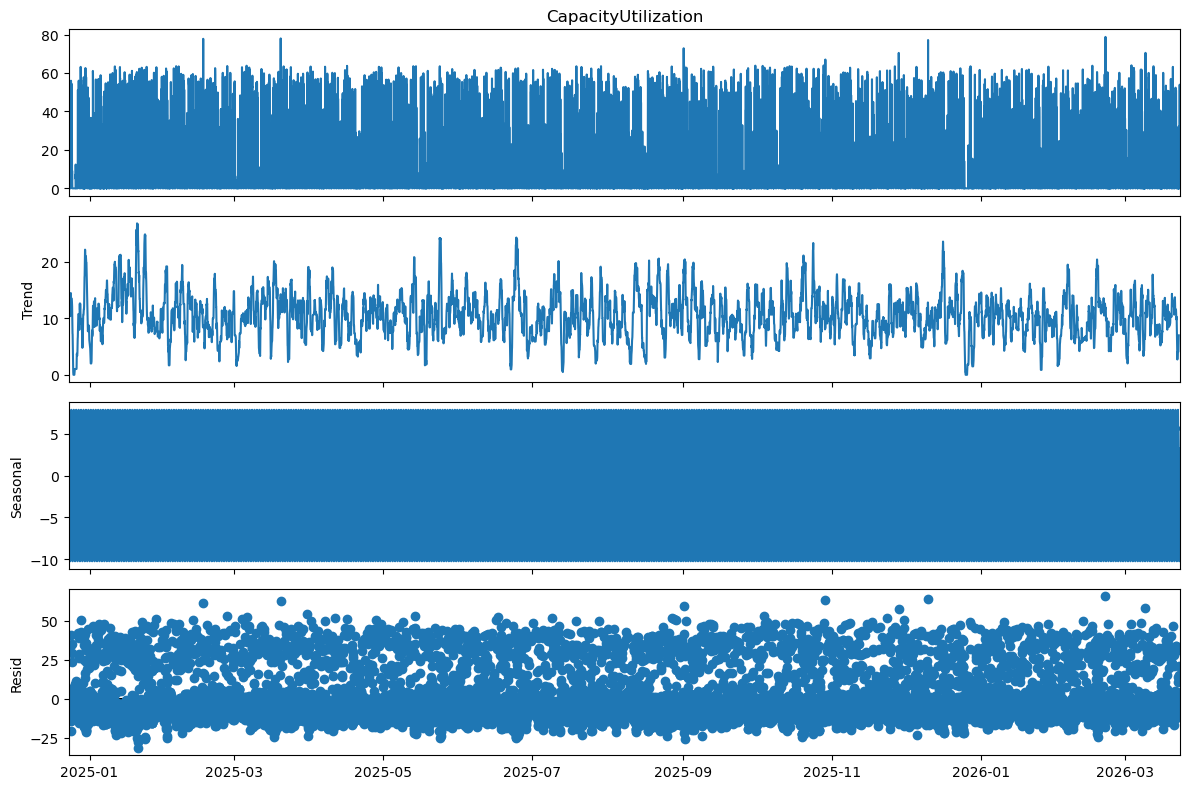

In [11]:
print("--- COMPONENT ANALYSIS (MODEL LOGIC) ---")
# Seasonal Decomposition
# Shows patterns (trend and seasonality) the model will 'learn' to recognize.
# We use interpolate() to safely handle any occasional missing data (NaNs) in the series.
analysis = seasonal_decompose(df['CapacityUtilization'].interpolate(), model='additive', period=24)

# Set figure size for better readability and plot the decomposition
plt.rcParams["figure.figsize"] = (12, 8)
analysis.plot()
plt.show()

In [12]:
# Context variables for Chronos-2
# Extracting temporal features directly from the datetime index
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek

# Adding Italian holidays (cloud load often drops/changes on holidays)
it_holidays = holidays.Italy()
df['is_holiday'] = df.index.map(lambda x: int(x in it_holidays))

print("Covariates successfully created.")
print(df[['hour', 'day_of_week', 'is_holiday']].head())


Covariates successfully created.
                     hour  day_of_week  is_holiday
TimeStamp                                         
2024-12-23 11:00:00    11            0           0
2024-12-23 12:00:00    12            0           0
2024-12-23 13:00:00    13            0           0
2024-12-23 14:00:00    14            0           0
2024-12-23 15:00:00    15            0           0


In [13]:
print("--- FORMATTING AND SAVING ---")

# 1. Adaptation for Chronos-2
# Reset the index to make TimeStamp a standard column again
df = df.reset_index()

# Add the mandatory identification column for Chronos-2
df['item_id'] = 'appstream_fleet'

# 2. Save the processed dataset
# index=False is crucial to avoid exporting row numbers to the CSV
df.to_csv(output_path, index=False)

print(f"Dataset ready for Chronos-2 saved at: {output_path}")

--- FORMATTING AND SAVING ---
Dataset ready for Chronos-2 saved at: c:\Users\alice\Apra\predictive-autoscaler-ml\datasets\Dati_processed.csv
